<a href="https://colab.research.google.com/github/zshane57/wings_eft_docker/blob/main/flieswings_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the necessary vision, ML, and math libraries
!pip install -q transformers torch torchvision opencv-python pyefd pandas matplotlib huggingface_hub

In [ ]:
#@markdown In order to use this colab:
#@markdown - Create an account on [hugging face](https://huggingface.co/)
#@markdown - Request the model access on [hugging face](https://huggingface.co/facebook/sam3)
#@markdown - Get your auth token from `Profile > Access tokens > Create New Token` on [hugging face](https://huggingface.co/settings/tokens)
#@markdown - Select the T4 GPU accelerator at `Runtime > Change runtime type > Hardware accelerator`
#@markdown - Click `Runtime > Run all`

#@markdown Note: beware that installing models for the first time will take some time.
hf_token = "" # @param {type:"string"}

In [ ]:
import torch
# IMPORT FIX: We are now importing the Tracker classes for point prompts
from transformers import Sam3TrackerProcessor, Sam3TrackerModel
from huggingface_hub import login

# Authenticate with Hugging Face to access the SAM 3 weights
login(token=hf_token)

# Assign the Colab T4 GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using compute device: {device}")

# CLASS FIX: Load the point-based Tracker model and processor
processor = Sam3TrackerProcessor.from_pretrained("facebook/sam3")
model = Sam3TrackerModel.from_pretrained("facebook/sam3").to(device)

Using compute device: cpu


processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam3_tracker`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_wing_image(image_obj, points, labels):
    """
    Runs SAM3 with multi-point prompts, traces the wing cell contour,
    and returns the raw boundary coordinates (X, Y) and the binary mask.
    """
    # 1. Prepare SAM 3 input tensors for MULTIPLE points
    inputs = processor(
        images=image_obj,
        input_points=[[points]],
        input_labels=[[labels]],
        return_tensors="pt"
    ).to(device)

    # 2. Run Inference
    with torch.no_grad():
        outputs = model(**inputs)

    # 3. Extract the highest confidence mask
    original_sizes = inputs["original_sizes"].cpu()
    if "reshaped_input_sizes" in inputs:
        reshaped_sizes = inputs["reshaped_input_sizes"].cpu()
        masks = processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(), original_sizes, reshaped_sizes
        )
    else:
        masks = processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(), original_sizes
        )

    scores = outputs.iou_scores
    best_mask_idx = torch.argmax(scores[0, 0])
    binary_mask = masks[0][0, best_mask_idx].numpy().astype(np.uint8)

    # 4. Extract boundary contours using OpenCV
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        print("Segmentation failed: No contour found.")
        return None, None # Return None for mask as well if contour fails

    # Get the largest continuous contour and squeeze it into a clean (N, 2) array of [X, Y] coordinates
    largest_contour = max(contours, key=cv2.contourArea).squeeze()

    # 5. Visualization Check
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(image_obj)

    points_arr = np.array(points)
    ax[0].plot(points_arr[0, 0], points_arr[0, 1], 'g*', markersize=14, label="Inclusive Prompt")
    if len(points_arr) > 1:
        ax[0].plot(points_arr[1:, 0], points_arr[1:, 1], 'rX', markersize=12, label="Exclusive Prompts")

    ax[0].set_title("Input Image & Prompts")
    ax[0].legend()
    ax[0].axis('off')

    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].plot(largest_contour[:, 0], largest_contour[:, 1], 'r-', linewidth=2)
    ax[1].set_title("SAM 3 Mask & Extracted Contour")
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Success! Extracted {len(largest_contour)} boundary coordinates.")

    # 6. Return the raw contour object AND the binary mask
    return largest_contour, binary_mask

In [ ]:
import os
from google.colab import drive
from PIL import Image
import torch
from transformers import Sam3Processor, Sam3Model

# Please approve to mount to Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import io
import base64
from IPython.display import display, HTML
from google.colab.output import eval_js

def get_click_coordinates(image):
    """
    Displays the image interactively in Colab.
    Waits for the user to click 3 times (1 inclusive, 2 exclusive) and returns the coordinates.
    """
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    img_str = base64.b64encode(buffer.getvalue()).decode()

    js_code = f"""
    new Promise(resolve => {{
        let clicks = [];

        let container = document.createElement('div');
        container.style.position = 'relative';
        container.style.display = 'inline-block';

        let h3 = document.createElement('h3');
        h3.style.color = '#4CAF50';
        h3.style.fontFamily = 'sans-serif';
        h3.innerHTML = '🖱️ Click 1: Click INSIDE the target wing cell (Inclusive)';
        document.body.appendChild(h3);

        let img = document.createElement('img');
        img.src = "data:image/png;base64,{img_str}";
        img.style.maxWidth = "100%";
        img.style.border = "2px solid #ccc";
        img.style.cursor = "crosshair";

        img.onclick = function(e) {{
            if (clicks.length >= 3) return;

            let rect = img.getBoundingClientRect();
            let scaleX = img.naturalWidth / rect.width;
            let scaleY = img.naturalHeight / rect.height;

            let x = Math.round((e.clientX - rect.left) * scaleX);
            let y = Math.round((e.clientY - rect.top) * scaleY);

            clicks.push([x, y]);

            // Draw a visual dot where you clicked
            let marker = document.createElement('div');
            marker.style.position = 'absolute';
            marker.style.left = (e.clientX - rect.left - 5) + 'px';
            marker.style.top = (e.clientY - rect.top - 5) + 'px';
            marker.style.width = '10px';
            marker.style.height = '10px';
            marker.style.borderRadius = '50%';
            marker.style.border = '2px solid white';
            marker.style.pointerEvents = 'none'; // Prevents dot from blocking future clicks

            // Update instructions and dot colors based on which click this is
            if (clicks.length === 1) {{
                marker.style.backgroundColor = '#4CAF50'; // Green for inclusive
                h3.innerHTML = '🛑 Click 2: Click OUTSIDE the target cell (Exclusive)';
                h3.style.color = '#F44336';
            }} else if (clicks.length === 2) {{
                marker.style.backgroundColor = '#F44336'; // Red for exclusive
                h3.innerHTML = '🛑 Click 3: Click ONE MORE OUTSIDE the target cell (Exclusive)';
            }} else if (clicks.length === 3) {{
                marker.style.backgroundColor = '#F44336'; // Red for exclusive
                h3.innerHTML = '✅ Processing...';
                h3.style.color = '#2196F3';

                // Finish up and return the 3 coordinates back to Python
                setTimeout(() => {{
                    container.remove();
                    h3.remove();
                    resolve(clicks);
                }}, 500);
            }}
            container.appendChild(marker);
        }};

        container.appendChild(img);
        document.body.appendChild(container);
    }});
    """

    print("Loading interactive image... Waiting for your 3 clicks.")
    coords = eval_js(js_code)
    print(f"🎯 Coordinates captured: {coords}")
    return coords

In [ ]:
#@markdown Sample directory in drive
#@markdown If your file is in a subfolder (e.g., 'My Drive/Images/my_image.png'),
#@markdown please provide the path relative to 'My Drive/' (e.g., 'Images/my_image.png').
sample_files = 'Ch.albiceps.4_cleanup.png' # @param {type:"string"}

📸 Testing with image: Ch.albiceps.4_cleanup.png

🎯 STAGE 1: Tracing the 'pa2r' wing cell boundary (please expect 2-3min processing time)
Loading interactive image... Waiting for your 3 clicks.
🎯 Coordinates captured: [[663, 138], [644, 85], [670, 218]]


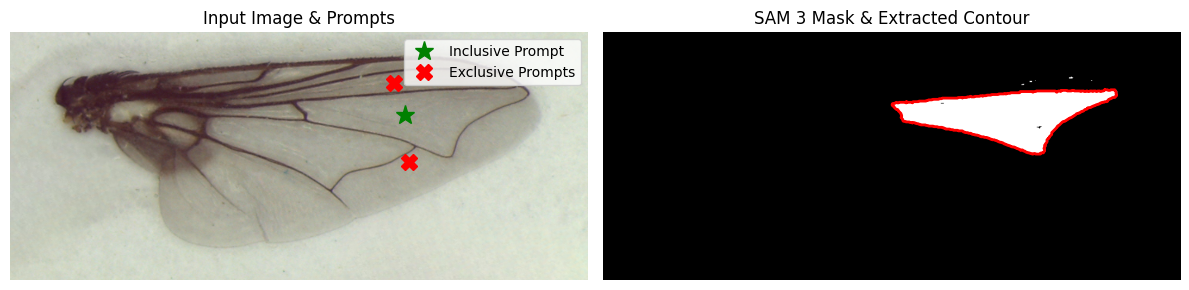

Success! Extracted 805 boundary coordinates.

🎯 STAGE 2: Tracing the 'dm' wing cell boundary (please expect 2-3min processing time)
Loading interactive image... Waiting for your 3 clicks.
🎯 Coordinates captured: [[486, 194], [469, 135], [476, 260]]


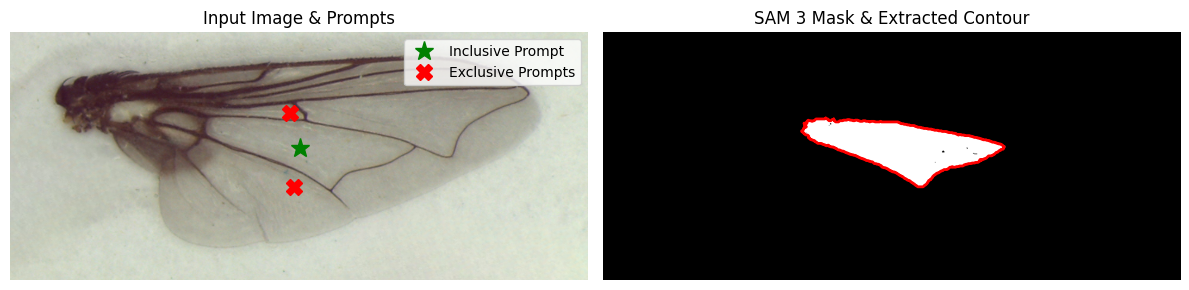

Success! Extracted 723 boundary coordinates.

✅ Success! Both contour objects and masks are now stored in memory.
Shape of pa2r_contour: (805, 2) (Rows of X,Y coordinates)
Shape of dm_contour: (723, 2) (Rows of X,Y coordinates)
Shape of pa2r_mask: (416, 970) (Binary mask dimensions)
Shape of dm_mask: (416, 970) (Binary mask dimensions)


In [ ]:
import os
from PIL import Image

# Per sample debug testing
input_folder = '/content/drive/My Drive/'

if not sample_files:
    print("No images found in the folder!")
else:
    test_filename = sample_files
    path = os.path.join(input_folder, test_filename)
    print(f"📸 Testing with image: {test_filename}")

    # Load the image
    image = Image.open(path).convert("RGB")

    # ---------------------------------------------------------
    # STAGE 1: Extract the pa2r Cell Contour
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("🎯 STAGE 1: Tracing the 'pa2r' wing cell boundary (please expect 2-3min processing time)")
    print("="*50)

    clicks_pa2r = get_click_coordinates(image)
    pa2r_contour, pa2r_mask = process_wing_image(
        image_obj=image,
        points=clicks_pa2r,
        labels=[1, 0, 0]
    )

    # ---------------------------------------------------------
    # STAGE 2: Extract the dm Cell Contour
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("🎯 STAGE 2: Tracing the 'dm' wing cell boundary (please expect 2-3min processing time)")
    print("="*50)

    clicks_dm = get_click_coordinates(image)
    dm_contour, dm_mask = process_wing_image(
        image_obj=image,
        points=clicks_dm,
        labels=[1, 0, 0]
    )

    print("\n✅ Success! Both contour objects and masks are now stored in memory.")
    print(f"Shape of pa2r_contour: {pa2r_contour.shape} (Rows of X,Y coordinates)")
    print(f"Shape of dm_contour: {dm_contour.shape} (Rows of X,Y coordinates)")
    print(f"Shape of pa2r_mask: {pa2r_mask.shape} (Binary mask dimensions)")
    print(f"Shape of dm_mask: {dm_mask.shape} (Binary mask dimensions)")

In [ ]:
import os
from PIL import Image

output_folder = '/content/drive/My Drive/segmented_masks'
os.makedirs(output_folder, exist_ok=True)

# Get the base filename from the original image for naming the masks
base_filename = os.path.splitext(os.path.basename(path))[0]

# Save pa2r_mask
if pa2r_mask is not None:
    pa2r_mask_image = Image.fromarray(pa2r_mask * 255) # Convert binary mask to 0-255 grayscale image
    pa2r_mask_path = os.path.join(output_folder, f'{base_filename}_pa2r_mask.png')
    pa2r_mask_image.save(pa2r_mask_path)
    print(f'pa2r mask saved to: {pa2r_mask_path}')
else:
    print('pa2r_mask was not generated or is None.')

# Save dm_mask
if dm_mask is not None:
    dm_mask_image = Image.fromarray(dm_mask * 255) # Convert binary mask to 0-255 grayscale image
    dm_mask_path = os.path.join(output_folder, f'{base_filename}_dm_mask.png')
    dm_mask_image.save(dm_mask_path)
    print(f'dm mask saved to: {dm_mask_path}')
else:
    print('dm_mask was not generated or is None.')

print(f'\nAll segmented masks have been saved to {output_folder} in your Google Drive.')

pa2r mask saved to: /content/drive/My Drive/segmented_masks/Ch.albiceps.4_cleanup_pa2r_mask.png
dm mask saved to: /content/drive/My Drive/segmented_masks/Ch.albiceps.4_cleanup_dm_mask.png

All segmented masks have been saved to /content/drive/My Drive/segmented_masks in your Google Drive.


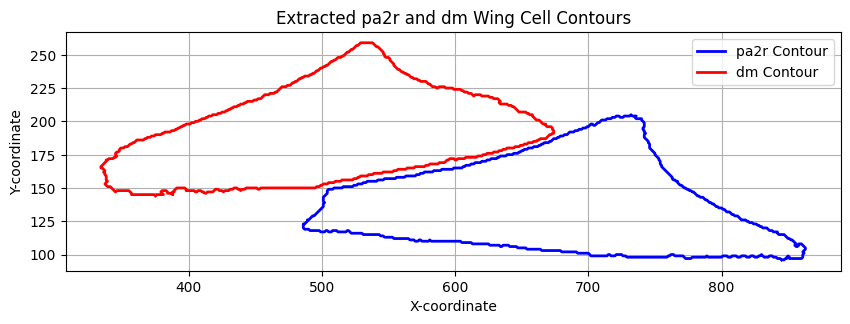

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and an axes object
plt.figure(figsize=(10, 8))

# Plot the pa2r_contour
plt.plot(pa2r_contour[:, 0], pa2r_contour[:, 1], color='blue', linewidth=2, label='pa2r Contour')

# Plot the dm_contour
plt.plot(dm_contour[:, 0], dm_contour[:, 1], color='red', linewidth=2, label='dm Contour')

# Add labels and title
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.title('Extracted pa2r and dm Wing Cell Contours')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

In [ ]:
# Vertically flip the contours by multiplying the y-coordinates by -1
flipped_pa2r_contour = pa2r_contour.copy()
flipped_pa2r_contour[:, 1] = -flipped_pa2r_contour[:, 1]

flipped_dm_contour = dm_contour.copy()
flipped_dm_contour[:, 1] = -flipped_dm_contour[:, 1]

print("Original pa2r_contour (first 5 rows):")
print(pa2r_contour[:5])
print("\nFlipped pa2r_contour (first 5 rows):")
print(flipped_pa2r_contour[:5])

print("\nOriginal dm_contour (first 5 rows):")
print(dm_contour[:5])
print("\nFlipped dm_contour (first 5 rows):")
print(flipped_dm_contour[:5])

Original pa2r_contour (first 5 rows):
[[845  96]
 [844  97]
 [843  97]
 [842  97]
 [841  98]]

Flipped pa2r_contour (first 5 rows):
[[845 -96]
 [844 -97]
 [843 -97]
 [842 -97]
 [841 -98]]

Original dm_contour (first 5 rows):
[[375 144]
 [374 145]
 [373 145]
 [372 145]
 [371 145]]

Flipped dm_contour (first 5 rows):
[[ 375 -144]
 [ 374 -145]
 [ 373 -145]
 [ 372 -145]
 [ 371 -145]]


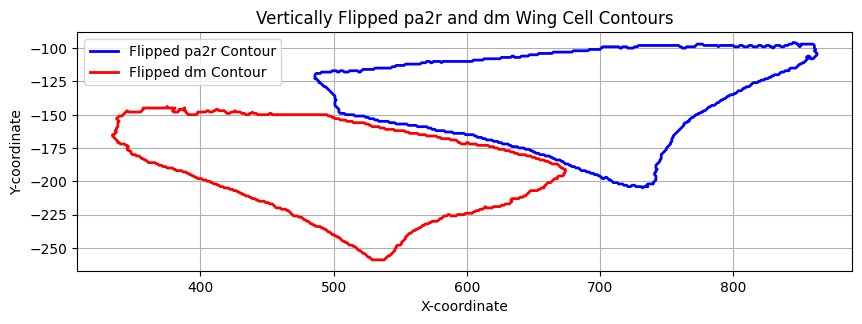

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the flipped contours
plt.figure(figsize=(10, 8))

# Plot the flipped_pa2r_contour
plt.plot(flipped_pa2r_contour[:, 0], flipped_pa2r_contour[:, 1], color='blue', linewidth=2, label='Flipped pa2r Contour')

# Plot the flipped_dm_contour
plt.plot(flipped_dm_contour[:, 0], flipped_dm_contour[:, 1], color='red', linewidth=2, label='Flipped dm Contour')

# Add labels and title
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.title('Vertically Flipped pa2r and dm Wing Cell Contours')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Get the maximum length of the contours
max_len = max(len(flipped_pa2r_contour), len(flipped_dm_contour))

# Convert contours to float type to allow NaN padding, then pad the shorter contour
padded_pa2r_x = np.pad(flipped_pa2r_contour[:, 0].astype(np.float32), (0, max_len - len(flipped_pa2r_contour)), 'constant', constant_values=np.nan)
padded_pa2r_y = np.pad(flipped_pa2r_contour[:, 1].astype(np.float32), (0, max_len - len(flipped_pa2r_contour)), 'constant', constant_values=np.nan)

padded_dm_x = np.pad(flipped_dm_contour[:, 0].astype(np.float32), (0, max_len - len(flipped_dm_contour)), 'constant', constant_values=np.nan)
padded_dm_y = np.pad(flipped_dm_contour[:, 1].astype(np.float32), (0, max_len - len(flipped_dm_contour)), 'constant', constant_values=np.nan)

# Create a dictionary for the DataFrame
data = {
    'dm_x': padded_dm_x,
    'dm_y': padded_dm_y,
    'pa2r_x': padded_pa2r_x,
    'pa2r_y': padded_pa2r_y
}

# Create the DataFrame
df_contours = pd.DataFrame(data)

# Save the DataFrame to a CSV file
output_csv_path = '/content/drive/My Drive/contours_coordinates.csv'
df_contours.to_csv(output_csv_path, index=False)

print(f"Contour coordinates saved to {output_csv_path}")
print("First 5 rows of the saved data:")
display(df_contours.head())


Contour coordinates saved to /content/drive/My Drive/contours_coordinates.csv
First 5 rows of the saved data:


,dm_x,dm_y,pa2r_x,pa2r_y
0,375.0,-144.0,845.0,-96.0
1,374.0,-145.0,844.0,-97.0
2,373.0,-145.0,843.0,-97.0
3,372.0,-145.0,842.0,-97.0
4,371.0,-145.0,841.0,-98.0
